In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✅")

Libraries loaded ✅


In [3]:
conn = sqlite3.connect("../data/bank_loan.db")
df = pd.read_sql("SELECT * FROM clean_data", conn)
conn.close()

print("Shape:", df.shape)
df.head()

Shape: (5000, 12)


,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,0.0,1,0,0,1,0,0,0
1,45,19,34,3,0.0,1,0,0,1,0,0,0
2,39,15,11,1,0.0,1,0,0,0,0,0,0
3,35,9,100,1,0.0,2,0,0,0,0,0,0
4,35,8,45,4,0.0,2,0,0,0,0,0,1


In [4]:
df.describe().round(2)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,45.34,20.12,73.77,2.40,0.0,1.88,56.50,0.10,0.10,0.06,0.60,0.29
std,11.46,11.44,46.03,1.15,0.0,0.84,101.71,0.29,0.31,0.24,0.49,0.46
min,23.00,0.00,8.00,1.00,0.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,35.00,10.00,39.00,1.00,0.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,45.00,20.00,64.00,2.00,0.0,2.00,0.00,0.00,0.00,0.00,1.00,0.00
75%,55.00,30.00,98.00,3.00,0.0,3.00,101.00,0.00,0.00,0.00,1.00,1.00
max,67.00,43.00,224.00,4.00,0.0,3.00,635.00,1.00,1.00,1.00,1.00,1.00


In [5]:
total    = len(df)
approved = df["Personal Loan"].sum()
rejected = total - approved

print(f"Total Customers     : {total}")
print(f"Loan Approved       : {approved}  ({approved/total*100:.1f}%)")
print(f"Loan Rejected       : {rejected}  ({rejected/total*100:.1f}%)")
print(f"Avg Income (Approved): ${df[df['Personal Loan']==1]['Income'].mean():.0f}K")
print(f"Avg Income (Rejected): ${df[df['Personal Loan']==0]['Income'].mean():.0f}K")

Total Customers     : 5000
Loan Approved       : 480  (9.6%)
Loan Rejected       : 4520  (90.4%)
Avg Income (Approved): $145K
Avg Income (Rejected): $66K


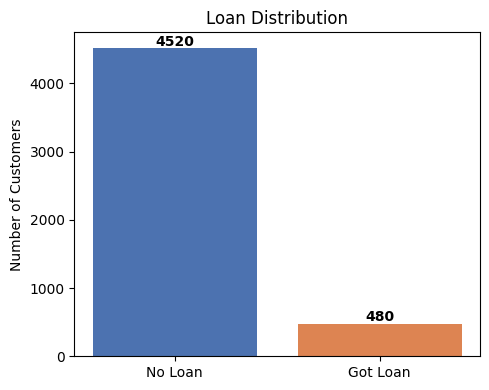

Only 9.6% customers accepted the loan — data is imbalanced!


In [6]:
counts = df["Personal Loan"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(["No Loan", "Got Loan"], counts.values, color=["#4C72B0", "#DD8452"])
plt.title("Loan Distribution")
plt.ylabel("Number of Customers")
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print("Only 9.6% customers accepted the loan — data is imbalanced!")

<Figure size 500x400 with 0 Axes>

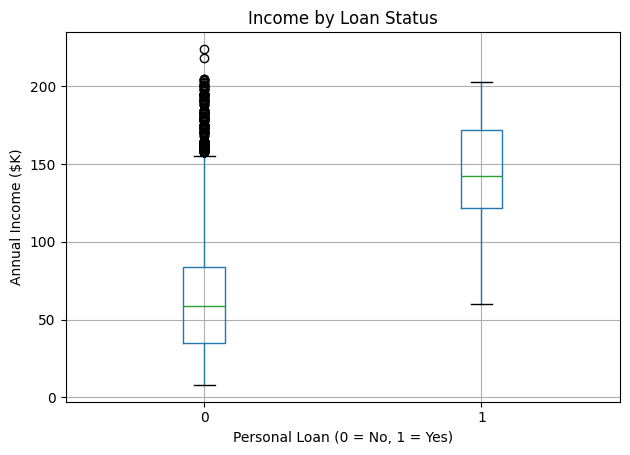

Yes! Loan takers earn significantly more on average.


In [7]:
plt.figure(figsize=(5, 4))
df.boxplot(column="Income", by="Personal Loan")
plt.title("Income by Loan Status")
plt.suptitle("")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Annual Income ($K)")
plt.tight_layout()
plt.show()

print("Yes! Loan takers earn significantly more on average.")

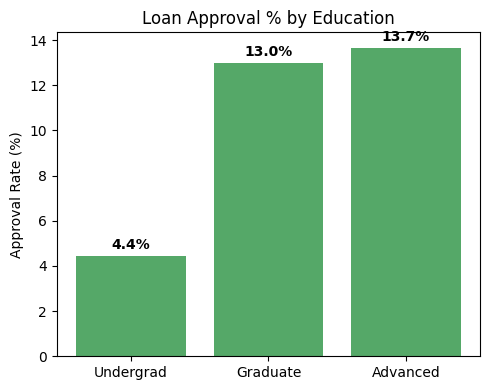

In [8]:
edu_loan = df.groupby("Education")["Personal Loan"].mean() * 100

plt.figure(figsize=(5, 4))
plt.bar(["Undergrad", "Graduate", "Advanced"], edu_loan.values, color="#55A868")
plt.title("Loan Approval % by Education")
plt.ylabel("Approval Rate (%)")
for i, v in enumerate(edu_loan.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

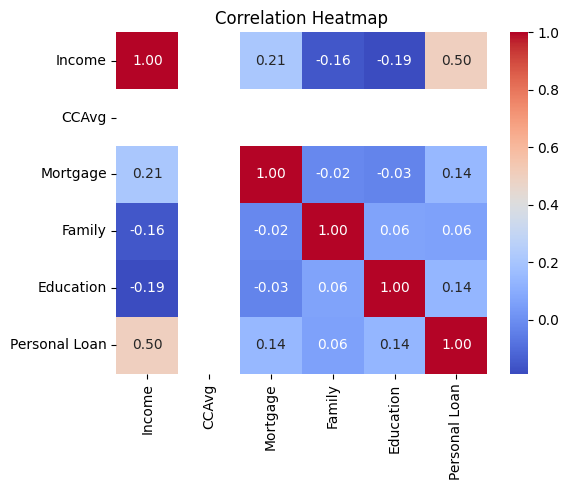

Income has the strongest correlation with Personal Loan!


In [9]:
key_cols = ["Income", "CCAvg", "Mortgage", "Family", "Education", "Personal Loan"]
corr = df[key_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Income has the strongest correlation with Personal Loan!")

- Only **9.6%** customers accepted the loan
- **Income** is the biggest factor — loan takers earn ~$145K vs $66K
- **Advanced degree** holders are more likely to accept
- **CD Account** holders have 46% loan acceptance rate